In [1]:
import pandas as pd
df = pd.read_csv('delta3_results_clean.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(29, 13)
['L', 'Delta3_Riemann', 'Delta3_Riemann_SE', 'Delta3_GUE_numerical', 'Delta3_GUE_SE', 'Delta3_GUE_asymptotic', 'discrepancy', 'sigma_sum', 'z_score', 'dDelta_dlogL', 'gap_from_plateau', 'frac_gap', 'rel_dev_gue']


,L,Delta3_Riemann,Delta3_Riemann_SE,Delta3_GUE_numerical,Delta3_GUE_SE,Delta3_GUE_asymptotic,discrepancy,sigma_sum,z_score,dDelta_dlogL,gap_from_plateau,frac_gap,rel_dev_gue
0,2,0.093747,0.000648,0.094412,0.000202,0.291252,0.000665,0.000679,0.978415,0.043226,0.097010,0.508552,0.007039
1,3,0.111274,0.000713,0.115156,0.000373,0.332334,0.003882,0.000805,4.825633,0.043630,0.079483,0.416673,0.033714
2,4,0.123908,0.000733,0.129803,0.000463,0.361482,0.005896,0.000867,6.799492,0.042907,0.066850,0.350443,0.045420
3,5,0.133307,0.000730,0.140982,0.000567,0.384091,0.007675,0.000925,8.300117,0.040336,0.057450,0.301167,0.054439
4,6,0.140395,0.000740,0.150442,0.000613,0.402564,0.010047,0.000961,10.455683,0.040033,0.050362,0.264012,0.066784


In [2]:
print(df[['L','Delta3_Riemann','Delta3_Riemann_SE','gap_from_plateau']].tail(10))
# Identify the empirical plateau
plateau_est = df['Delta3_Riemann'].iloc[-1]
print("Last L:", df['L'].iloc[-1], "Delta3_Riemann:", plateau_est)

       L  Delta3_Riemann  Delta3_Riemann_SE  gap_from_plateau
19   145        0.185121           0.000136      5.636697e-03
20   180        0.186159           0.000129      4.597903e-03
21   223        0.187164           0.000125      3.593466e-03
22   276        0.188153           0.000121      2.604328e-03
23   342        0.189104           0.000116      1.653490e-03
24   424        0.190043           0.000112      7.139079e-04
25   526        0.190756           0.000112      1.745980e-06
26   651        0.190758           0.000123     -1.141852e-06
27   807        0.190758           0.000136     -5.873276e-07
28  1000        0.190755           0.000150      2.423363e-06
Last L: 1000 Delta3_Riemann: 0.1907548872960174


In [3]:
import numpy as np
from sympy import primerange, isprime

# Berry (1988) gives, for the saturated number variance of Riemann zeros at large L:
#   Sigma^2_infty = (1/pi^2) * sum_p sum_{k>=1} (log p)^2 / p^k   * something? 
# Let me be careful. Berry's formula for the asymptotic Delta_3:
#   Delta_3(L) -> Delta_3^infty = (1/pi^2) * sum_p sum_{k>=1} (1/k^2) * (1 - cos(...))  ... 
# Actually the standard result from Berry 1988 "Semiclassical formula for number variance of Riemann zeros":
# Sigma^2_infty(L->infty) = (1/pi^2) * [sum_p sum_k (log p)^2 / (k^2 * p^k) ... ]
# 
# Let me check more carefully. The conjectured asymptotic value reported by Berry is:
# Delta_3^infty = (1/(2*pi^2)) * [ ln(ln(T/2pi)) + gamma_E + ... ] for the saturation scale
# But the *saturation value* (limit as L->infty *after* the saturation scale is set by T) is:
#
# Actually re-read: the saturation plateau is a function of T (the height up to which zeros are computed).
# For random matrix / GUE, Delta_3 ~ (1/pi^2)*(ln L + ...).
# For Riemann zeros, Delta_3 saturates because primes provide a cutoff.
#
# Berry's formula: Sigma^2(L; T) has two pieces. For L >> some scale set by smallest prime,
# Delta_3(L) -> Delta_3^infty(T) = (1/pi^2) [ ln(2*pi) - 1 - (gamma+ln(2pi))... ]
# 
# Hmm. Let me look at this more carefully. The hypothesis statement gives a specific formula:
#   Delta3_inf = (1/(2 pi^2)) * sum_{p,k} (log p)^2 / p^k
# 
# Let's compute that.

# Compute sum over primes p and k>=1 of (log p)^2 / p^k
# = sum over primes p of (log p)^2 * sum_{k>=1} 1/p^k
# = sum over primes p of (log p)^2 * (1/(p-1))

primes = list(primerange(2, 10_000_000))
print(f"Num primes up to 10^7: {len(primes)}")
s = 0.0
for p in primes:
    s += (np.log(p))**2 / (p - 1)
print(f"sum_p (log p)^2 / (p-1) = {s}")
val = s / (2 * np.pi**2)
print(f"Delta3_inf (hypothesis form) = {val}")

Num primes up to 10^7: 664579


sum_p (log p)^2 / (p-1) = 128.32701219967433
Delta3_inf (hypothesis form) = 6.501122384677862


In [4]:
# That value (6.5) is way too large. The hypothesis-given formula doesn't converge to ~0.19.
# Need to look at the actual Berry/Bogomolny-Keating formula.
# 
# Berry 1988 actually has the formula:
# Sigma^2(L) = Sigma^2_GUE(L) + Sigma^2_osc + Sigma^2_arith
# where for large L (saturation):
#   Sigma^2_infty = (1/pi^2) * sum_p sum_{k} (1/k^2) * something with cutoff
# 
# The standard reference result (e.g., Berry-Keating reviews):
# In the regime 1/Tbar << L*Tbar << T_H (Heisenberg time), Delta_3 saturates at
#   Delta_3^infty(T) = (1/(2*pi^2)) * [ ln(T/(2*pi)) - <something> ]
# Wait no, the saturation actually DEPENDS on T (height of zeros). At T~10^6 ish.
#
# Let me actually compute Berry's formula. From Berry 1988 (RSPA 1988):
# For T -> infty, the Riemann zeros' number variance saturates to:
# 
# Sigma^2_inf(T) = (1/pi^2) [ ln(T_bar) + gamma + 1 + sum over primes... ]
# where T_bar = T/(2pi) * ln(T/(2pi)) (mean level spacing inverse)
#
# Hmm, but for Delta_3 the saturation value is:
# Delta_3^inf(T) = (1/pi^2) [ ln(ln(T/(2pi))) + gamma - 5/4 - pi^2/8 + sum over primes ... ]
# This is a constant + log(log(T)).
# 
# Actually a cleaner statement: Bogomolny & Keating (1996) show
#   Delta_3^inf = (1/pi^2) * ln( T_H / tau_min )
# where tau_min is set by the smallest prime period tau_min = log(2)/(2pi) and T_H is Heisenberg.
#
# Let's pursue: for zeros up to height T, mean density is bar{d}(T) = (1/2pi) log(T/2pi)
# Heisenberg time T_H = 2pi * bar{d} = log(T/2pi)
# Shortest periodic orbit period tau_min = log(2)
# 
# Then Delta_3^inf ≈ (1/(2*pi^2)) * ln(T_H / tau_min)^2  ? Let's check the precise formula.

# From Berry 1988 Eq for Sigma^2 asymptotic:
# Sigma^2_inf(T) = (1/pi^2)[ ln(T/(2pi) * log(T/(2pi)) / (log 2)) + gamma + 1 - C_2 ]
# 
# where C_2 = sum_p [ (log p)^2 * (p-1) - p log^2 p ] / ... 
# 
# This is getting complex. Let me search for the actual formula.

# Actually, the *simplest* and most cited form (Berry 1988):
# Delta_3^inf = (1/pi^2) * [ ln(2*pi*<d>) - gamma - 5/4 + (pi^2/8) ] 
#             - (1/(2*pi^2)) * sum_p sum_{k>=1} (1/k^2) * Ci(k * L * log(p))
# where <d> is mean density. The saturation comes from the prime sum.

# But our hypothesis gives a specific formula. Let me check if it might be:
# Delta_3^inf = (1/(2 pi^2)) * sum_p sum_k (log p)^2 / (k^2 * p^k)
# (note the k^2 in denominator from Sigma^2 integration)

s2 = 0.0
for p in primes:
    lp = np.log(p)
    for k in range(1, 60):
        term = (lp**2) / (k**2 * p**k)
        s2 += term
        if term < 1e-25:
            break
print("sum (log p)^2/(k^2 p^k) =", s2)
print("/(2 pi^2) =", s2/(2*np.pi**2))

sum (log p)^2/(k^2 p^k) = 127.55158734589034
/(2 pi^2) = 6.461838902672321


In [5]:
# Still too large. Let me carefully derive from Berry 1988.
# 
# Berry's formula for the number variance of Riemann zeros:
# Sigma^2(L) = Sigma^2_GUE(L)  for L << L* (universal regime)
# Sigma^2(L) = Sigma^2_inf      for L >> L* (saturation)
#
# Berry's prime-sum expression (1988, eq. for Sigma^2):
# Sigma^2_inf(T) = (2/pi^2) * sum_{p,k} (1/k^2) sin^2(k*L*log(p)/2) / p^k  ... averaged
# As L -> infty after averaging, sin^2 averages to 1/2, giving:
# Sigma^2_inf = (1/pi^2) * sum_{p,k} 1/(k^2 p^k)
#
# Hmm, but this has no log(p)^2! Let me reconsider.
#
# Actually Berry 1988 formula:
# Sigma^2(L,T) = (1/pi^2)[ ln(L) + gamma + 1 + pi^2/8 ] - (2/pi^2) sum_{p,k} (1/k^2/p^k) cos(k L log p / d_bar^{-1})... 
# 
# The unfolded variance saturates because the cosine oscillates with frequency depending on prime.
# At saturation:
# Sigma^2_inf = (1/pi^2)[ ln(2*pi*d_bar) + gamma + 1 ] - (2/pi^2) sum_{p,k} 1/(k^2 p^k)
# where d_bar = (1/2pi) log(T/2pi).
#
# Then Delta_3 relates to Sigma^2 by:
# Delta_3(L) = (2/L^4) integral_0^L (L^3 - 2L^2 r + r^3) Sigma^2(r) dr
# 
# For large L (saturation), Delta_3 -> Sigma^2_inf / 2  (since integral of constant times stuff -> const)
# Wait actually:
# If Sigma^2(L) -> Sigma^2_inf (constant) for L > L*, then
# Delta_3(L) ~ Sigma^2_inf - <something decaying>
# More precisely, Delta_3(L)/Sigma^2(L) -> 1 - ... 
# 
# In the GUE limit, Sigma^2(L) ~ (1/pi^2)(ln L + ...) and Delta_3(L) ~ (1/pi^2)(ln L + ...)/2 ??
# Let me check: GUE asymptotic Delta_3(L) ~ (1/pi^2)*(ln(2 pi L) + gamma - 5/4 - pi^2/8)
# GUE asymptotic Sigma^2(L) ~ (1/pi^2)*(ln(2 pi L) + gamma + 1 - pi^2/8)
# So Delta_3 ~ Sigma^2 minus a constant.
# 
# For saturation: Delta_3_inf has its own constant.
# 
# Let me try a different version: maybe Berry's formula gives
# Delta_3^inf(T) ≈ (1/(2pi^2)) * ln(T_H / tau_p_min) where T_H = log(T/2pi)
# 
# With T ~ height of largest zero in dataset.
# Need T from the dataset context. The Δ_3 was computed using first million zeros. T ~ 600000 ish.

# Let me estimate T_H
T = 600269.677  # height of 10^6-th zero approximately
T_H = np.log(T/(2*np.pi))
print("T_H =", T_H)
# Smallest prime period: tau = log(2)
tau_min = np.log(2)
print("tau_min =", tau_min)

# Plateau according to Bogomolny-Keating semiclassical estimate
# A common estimate (Berry 1988 eq 33):
# Delta_3^inf(T) = (1/pi^2)[ ln(L_max) + gamma + 5/4 - pi^2/8 ]
# where L_max = T_H / tau_min, but actually a sharper formula:

# Berry 1988 Eq. (33): Delta_3(infty, T) = (1/(2*pi^2))*[ln(T/(2*pi)) + C_E]
# Actually let me just look up directly via web

print()
print("First try: Delta_3^inf ≈ (1/(2 pi^2)) * (ln(T_H) + gamma)")
gamma_E = 0.5772156649
print((1/(2*np.pi**2))*(np.log(T_H) + gamma_E))

# Another estimate Berry-Keating:
print("Delta_3^inf ≈ (1/(2 pi^2)) * ln(T/(2 pi))")
print((1/(2*np.pi**2)) * np.log(T/(2*np.pi)))

T_H = 11.467257228477965
tau_min = 0.6931471805599453

First try: Delta_3^inf ≈ (1/(2 pi^2)) * (ln(T_H) + gamma)
0.15282838699368786
Delta_3^inf ≈ (1/(2 pi^2)) * ln(T/(2 pi))
0.5809380377602706


In [6]:
# The hypothesis as literally stated has a divergent sum and doesn't match 0.1908.
# Let me carefully implement the proper Berry 1988 / Bogomolny-Keating semiclassical
# saturation formula and compare it to the empirical plateau.
#
# Berry 1988 (Nonlinearity 1, 399), Eq. (33) for the saturation value of Sigma^2:
# Sigma^2_inf(T) = (1/pi^2)[ ln(T_H) + gamma + 1 - C_arith ]
# where T_H = log(T/(2pi)) is the Heisenberg time (in unfolded units), and
# C_arith = sum_p sum_{k>=1} (1/(k^2 p^k)) * [ k log p / (k log p) ]  ... 
# 
# A cleaner statement (Berry 1985, Berry-Keating 1999):
# The arithmetic contribution to the number variance saturates at
#   Sigma^2_inf = (1/pi^2) * 2 * sum_{p,k} (1 - cos(k log p * L))/(k^2 p^k)
# As L -> inf, average of cos -> 0, so Sigma^2_inf = (2/pi^2) sum (1/(k^2 p^k))
# 
# Wait that gives a finite number! Let me compute.

s = 0.0
for p in primes:
    for k in range(1, 60):
        term = 1.0 / (k**2 * p**k)
        s += term
        if term < 1e-25:
            break
print("sum 1/(k^2 p^k) =", s)
print("2/pi^2 * sum =", 2/np.pi**2 * s)
print("1/pi^2 * sum =", 1/np.pi**2 * s)
print("1/(2 pi^2) * sum =", 1/(2*np.pi**2) * s)

sum 1/(k^2 p^k) = 3.180920019425888
2/pi^2 * sum = 0.644589162879678
1/pi^2 * sum = 0.322294581439839
1/(2 pi^2) * sum = 0.1611472907199195


In [7]:
# Interesting -- (1/(2 pi^2)) * sum_{p,k} 1/(k^2 p^k) = 0.1611, which is closer.
# Note sum_p sum_{k>=1} 1/(k^2 p^k) = sum_p Li_2(1/p) = "prime zeta-like" sum
# 
# But the hypothesis claims the formula has (log p)^2 in numerator.
# 
# Let me look at the proper Berry formula more carefully.
# Berry & Keating "The Riemann Zeros and Eigenvalue Asymptotics" (SIAM Review 1999):
# The number variance for the Riemann zeros is:
# Sigma^2(L; T) = Sigma^2_GUE(L) - Sigma^2_GUE_subt + Sigma^2_arith(L, T)
# where the arithmetic part involves a sum over primes:
# Sigma^2_arith(L, T) = (1/pi^2) * Re sum_{p,k} (1/(k^2)) * (1 - exp(i k L log p / d_bar^{-1})) / p^k * cutoffs
# 
# The standard result (Berry 1988 Eq. 22) for the saturation value:
# Delta_3_inf = (1/pi^2)[ ln(L_max) + gamma - 5/4 ]  where L_max ≈ T_H / tau_min... but better:
# 
# Berry's *explicit* saturation:
# Delta_3_inf(T) = (1/pi^2) * (1/2) * sum_{p, k} (1/(k^2 p^k)) * [stuff with arctan/log] 
# 
# Let me try yet another formula. The Bogomolny-Keating 1996 saturation:
# Delta_3^inf = (1/pi^2) * sum_{p,k : k log p < T_H} (log p)^2 / (k^2 p^k)  ... 

# Hmm, that's the truncated version. Let me compute that with cutoff.
T_zeros = 600269.677  # height of millionth Riemann zero
# Actually let's use what's relevant. The Delta_3 from the data was computed using
# unfolded zeros, so the cutoff in unfolded time is T_H = log(T/(2 pi))
T_H_val = np.log(T_zeros/(2*np.pi))
print("T_H =", T_H_val)

# Truncated sum (cutoff at k log p <= T_H):
s_trunc = 0.0
for p in primes:
    lp = np.log(p)
    if lp > T_H_val:
        break  # primes are sorted, so all higher p with k=1 are excluded
    for k in range(1, 200):
        if k*lp > T_H_val:
            break
        term = (lp**2) / (k**2 * p**k)
        s_trunc += term
print("sum_{p,k: k log p <= T_H} (log p)^2/(k^2 p^k) =", s_trunc)
for prefac, name in [(1/np.pi**2, "1/pi^2"), (1/(2*np.pi**2), "1/(2pi^2)"), (2/np.pi**2, "2/pi^2")]:
    print(f"{name} * sum = {prefac * s_trunc}")

T_H = 11.467257228477965
sum_{p,k: k log p <= T_H} (log p)^2/(k^2 p^k) = 63.45464280761577
1/pi^2 * sum = 6.429299516869385
1/(2pi^2) * sum = 3.2146497584346925
2/pi^2 * sum = 12.85859903373877


In [8]:
# Still too big. Let me derive this properly from scratch using the explicit formula.
# 
# The explicit formula for the Riemann zeros gives a density:
# d(E) = d_bar(E) + d_osc(E)
# where d_osc(E) = -(1/pi) sum_{p,k} (log p / p^(k/2)) cos(k E log p)
#
# Then the unfolded number variance is:
# Sigma^2(L) = <(N(E+L) - N(E) - L)^2>
# = 2 * integral_0^inf (sin^2(pi y L)/(pi y)^2) K(y) dy  where K is the spectral form factor
#
# In semiclassical theory:
# K(tau) = K_GUE(tau) + K_arith(tau) (diagonal periodic orbits)
# K_arith(tau) = sum_{p,k} (log p)^2 / (k^2 p^k) * delta(tau - k log p / (2 pi d_bar))
# 
# Actually: the diagonal approximation gives
# K_diag(tau) = (2/d_bar) sum periodic orbits weight^2 / period * delta(tau - T_p/(2 pi d_bar))
#
# For Riemann zeros, periodic orbits are labeled by (p, k), with period T_p^(k) = k log p
# and amplitude A_p^(k) = log p / p^(k/2), so the squared amplitude / period contribution is:
# (log p)^2 / (k^2 p^k) ... times delta function
#
# Then Sigma^2(L) and Delta_3(L) at saturation: as L -> infty, sin^2 -> 1/2:
# Sigma^2_inf = sum over orbits of [2 * (1 - <cos>)/(...)^2 * weight]
# 
# OK let me just look at Berry's original paper to find Eq. for the saturation value.

import subprocess
# Try fetching the literature directly


In [9]:
from e14c.web import web_search
results = await web_search("Berry 1988 semiclassical formula number variance Riemann zeros saturation Delta_3 formula prime sum", num_results=8, category="scholarly")
for r in results[:8]:
    print(r['title'])
    print(r['url'])
    print(r.get('snippet','')[:300])
    print('---')

Quantum Chaos, Random Matrix Theory, and the Riemann ζ-function | Springer Nature Link
https://link.springer.com/chapter/10.1007/978-3-0348-0697-8_4
M.V. Berry, Semiclassical formula for the number variance of the Riemann zeros, Nonlinearity 1, 399–407 (1988).
---

https://arxiv.org/pdf/2211.14918
Abstract. Assuming the Riemann hypothesis, we prove estimates for the variance of the real and imaginary
[...]
part of the logarithm of the Riemann zeta-function in short intervals. We give three different formulations of
[...]
these results. Assuming a conjecture of Chan for how
[...]
gaps between 
---

https://arxiv.org/pdf/0712.0705
In 1999 Berry and Keating showed that a regularization of the 1D classical HamiltonianH=
[...]
xp gives semiclassically the smooth counting function of the Riemann zeros. In this paper we
[...]
first generalize this result by considering a phase space delimited by two boundary functions in
[...]
pos
---

https://arxiv.org/pdf/1903.07057
to an asymptotic formula

In [10]:
results = await web_search("Berry 1988 number variance Riemann zeros formula saturation \"log 2\" \"log p\" sum primes Delta_3 asymptotic", num_results=8)
for r in results[:8]:
    print(r['title'])
    print(r['url'])
    print(r.get('snippet','')[:400])
    print('---')

[PDF] The Riemann Zeros and Eigenvalue Asymptotics
https://empslocal.ex.ac.uk/people/staff/mrwatkin/zeta/berry-keating1.pdf
The Riemann Zeros and
[...]
Eigenvalue Asymptotics∗
[...]
Abstract. Comparison between formulae for the counting functions of the heights tn of the Riemann
[...]
zeros and of semiclassical quantum eigenvalues En suggests that the tn are eigenvalues of
[...]
The Riemann-Siegel formula for the zeta function is described in detail
[...]
tion as a relation between
[...]
speculation concerning the zero
---
Semiclassical formula for the number variance of the Riemann zeros - IOPscience
https://iopscience.iop.org/article/10.1088/0951-7715/1/3/001
Semiclassical formula
[...]
the number variance of the Riemann zeros - IOPscience
[...]
# Semic
[...]
formula for the
[...]
variance of the Riemann
[...]
Published under licence by IOP Publishing Ltd Nonlinearity, Volume 1, Number 3 Citation M V Berry 1988 Nonlinearity 1 399DOI 10.1088/0951-7715/1/3/001
[...]
By pretending that 

In [11]:
from e14c.web import fetch_parsed_page
text = await fetch_parsed_page("https://empslocal.ex.ac.uk/people/staff/mrwatkin/zeta/berry-keating1.pdf")
# Search for relevant sections
import re
# Find lines mentioning Delta_3 or saturation
lines = text.split('\n')
for i, ln in enumerate(lines):
    if any(k in ln.lower() for k in ['delta_3','number variance','sigma^2','saturat','asymptot','log p','prime sum']):
        print(i, ln)

In [12]:
print(len(text))
print(text[:2000])

582168
JVBERi0xLjINJeLjz9MNCjE4MyAwIG9iag08PCANL0xpbmVhcml6ZWQgMSANL08gMTg1IA0vSCBbIDE0ODcgMTQ0OCBdIA0vTCA0MzY2MjUgDS9FIDEwMjA2NyANL04gMzEgDS9UIDQzMjg0NiANPj4gDWVuZG9iag0gICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICB4cmVmDTE4MyA1MyANMDAwMDAwMDAxNiAwMDAwMCBuIA0wMDAwMDAxNDExIDAwMDAwIG4gDTAwMDAwMDI5MzUgMDAwMDAgbiANMDAwMDAwMzE1MyAwMDAwMCBuIA0wMDAwMDAzNDAxIDAwMDAwIG4gDTAwMDAwMDQzODAgMDAwMDAgbiANMDAwMDAwNDYxOSAwMDAwMCBuIA0wMDAwMDEwMjAxIDAwMDAwIG4gDTAwMDAwMjczMjQgMDAwMDAgbiANMDAwMDAzNTg1NiAwMDAwMCBuIA0wMDAwMDM2ODE3IDAwMDAwIG4gDTAwMDAwMzczNzMgMDAwMDAgbiANMDAwMDAzODE5MyAwMDAwMCBuIA0wMDAwMDM5MDA3IDAwMDAwIG4gDTAwMDAwMzkyMDYgMDAwMDAgbiANMDAwMDA0MDE5MSAwMDAwMCBuIA0wMDAwMDQ3NTE5IDAwMDAwIG4gDTAwMDAwNDc3MjggMDAwMDAgbiANMDAwMDA0ODcwNSAwMDAwMCBuIA0wMDAwMDQ5MDUzIDAwMDAwIG4gDTAwMDAwNDkzNTYgMDAwMDAgbiANMDAwMDA0OTYwMCAwMDAwMCBuIA0wMDAwMDQ5NjgwIDAwMDAwIG4gDTAwMDAwNTA2NTUgMDAwMDAgbiANMDAwMDA1MTYyMSAwMDAwMCBuIA0wMDAwMDU2NjY5IDAwMDAwIG4gDTAwMDAwNTY2OTEgMDAwMDAgbiANMDAwMDA1NzQ0MiAwMDAwMCBuI

In [13]:
# PDF was returned as base64 (raw bytes). Let me decode and parse.
import base64, io
try:
    pdf_bytes = base64.b64decode(text)
except Exception as e:
    print(e)
print("size:", len(pdf_bytes))

with open('/tmp/berry_keating.pdf','wb') as f:
    f.write(pdf_bytes)

# Use pypdf or pdfminer
import subprocess
r = subprocess.run(['python','-c','from pypdf import PdfReader; r=PdfReader("/tmp/berry_keating.pdf"); print(len(r.pages)); print(r.pages[0].extract_text()[:2000])'], capture_output=True, text=True)
print(r.stdout[:3000])
print('ERR:',r.stderr[:500])

size: 436625

ERR: Traceback (most recent call last):
  File "<string>", line 1, in <module>
    from pypdf import PdfReader; r=PdfReader("/tmp/berry_keating.pdf"); print(len(r.pages)); print(r.pages[0].extract_text()[:2000])
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'pypdf'



In [14]:
import subprocess
r = subprocess.run(['pip','install','-q','pypdf'], capture_output=True, text=True)
print(r.stdout[-500:], r.stderr[-500:])

In [15]:
from pypdf import PdfReader
reader = PdfReader("/tmp/berry_keating.pdf")
print(len(reader.pages))
all_text = []
for i,page in enumerate(reader.pages):
    all_text.append(page.extract_text())
big = '\n--PAGE %d--\n'.join(all_text)
# Search for relevant terms
import re
for kw in [r'number variance', r'saturat', r'\\Delta_?3', r'Sigma', r'log p', r'L_max', r'osc']:
    for m in re.finditer(kw, big, flags=re.IGNORECASE):
        start = max(0, m.start()-150); end = min(len(big), m.end()+200)
        print(f"--- match '{kw}' ---")
        print(big[start:end])
        print()
        break

31


--- match 'number variance' ---
sures that this requirement is
compatible with (4.2).
Other statistics that are bilinear in d can be expressed in terms of K or R.A
useful one is the number variance:
Σ2 (x) ≡ variance of number of levels or zeros in
an interval where the mean number is x
=
⣨[
N
(
y + 1
2 x
)
−N
(
y − 1
2 x
)
− x
]2⟩
= 2
π2
∫ ∞
0
dτ K (τ)
τ2 sin2 (πxτ)
= x +2
∫ x
0
dy (x − y)[R (

--- match 'log p' ---
fact that
this does not converge in the critical strip, and obtain the divergent but formally
exact expression
N
ﬂ (t)= − 1
πIm
∑
p
log
{
1 − exp (−itlog p)√p
}
= − 1
π
∑
p
∞∑
m=1
exp
(
−1
2 m log p
)
m sin{tm log p} .
(2.6)
This formula gives the ﬂuctuations as a series of oscillatory contributions, each labelled
by a prime p and an integer m, correspo

--- match 'osc' ---
M¨obius numbers (1,−1,−1,0,−1,1,... ) [7]. Each of the
partial densities J′ is the sum of a smooth part (dominated by (1.2)) and an inﬁnite
series of oscillations:
J′ (x)= 1
log x
(
1 − 1
x(x2 − 1)
)
− 

In [16]:
# This is Berry-Keating 1999. Let me search specifically for the saturation Delta_3 formula in this paper.
# Also try the Bogomolny & Keating 1996 paper directly.
# 
# Let me search the text for the relevant Delta_3 / Sigma^2 saturation formula.

for kw in [r'Σ2', 'saturat', 'Heisenberg', 'plateau', 'asymptot', 'long-range', '∆3', 'Delta', '\u2206']:
    matches = list(re.finditer(re.escape(kw) if '\\' not in kw else kw, big))
    if matches:
        print(f"\n=== keyword: '{kw}' ({len(matches)} matches) ===")
        for m in matches[:3]:
            start = max(0, m.start()-200); end = min(len(big), m.end()+400)
            print(big[start:end])
            print('---')


=== keyword: 'Σ2' (1 matches) ===
long range; the term δ(x)i n R ensures that this requirement is
compatible with (4.2).
Other statistics that are bilinear in d can be expressed in terms of K or R.A
useful one is the number variance:
Σ2 (x) ≡ variance of number of levels or zeros in
an interval where the mean number is x
=
⣨[
N
(
y + 1
2 x
)
−N
(
y − 1
2 x
)
− x
]2⟩
= 2
π2
∫ ∞
0
dτ K (τ)
τ2 sin2 (πxτ)
= x +2
∫ x
0
dy (x − y)[R (y) − 1].
(4.4)
The correlation function (4.1) is determined by the spectral density ﬂuctuations,
for which there is the semiclassical formula (2.16). Our aim in this section is to explain
how to employ th
---

=== keyword: 'Heisenberg' (5 matches) ===
individual levels it is necessary to include at least all those orbits with
periods up to
T
H (E)=2 πℏ ⟨d⟩ = O
( 1
ℏD−1
)
.(2.21)
This evokes the time-energy uncertainty relation, so TH is called the Heisenberg time.
Asymptotically, TH corresponds to very long orbits, or, in the Riemann case, large
primes pH(t)= t

In [17]:
# Let me look at section 4 for the explicit Sigma^2 formula
idx = big.find('Σ2 (x)')
print(big[idx:idx+5000])

Σ2 (x) ≡ variance of number of levels or zeros in
an interval where the mean number is x
=
⣨[
N
(
y + 1
2 x
)
−N
(
y − 1
2 x
)
− x
]2⟩
= 2
π2
∫ ∞
0
dτ K (τ)
τ2 sin2 (πxτ)
= x +2
∫ x
0
dy (x − y)[R (y) − 1].
(4.4)
The correlation function (4.1) is determined by the spectral density ﬂuctuations,
for which there is the semiclassical formula (2.16). Our aim in this section is to explain
how to employ this observation to calculate these bilinear statistics, obtaining not only
the universal random-matrix limit but also the corrections to this corresponding to
large eigenvalue or zero separations, or short times. The argument is subtle and has
several levels of reﬁnement, of which we start with the simplest [3, 5, 33].
We will calculate K(τ). The ﬁrst step is to substitute (2.16) into (4.1), thereby
obtaining a double sum over periodic orbits. Since all the actions are positive, we can
simplify the averages (over a small interval of eigenvalues or along the critical line)
using
⟨cos {S
j/ℏ} c

In [18]:
# Let me look at the section where the explicit Sigma^2 saturation formula appears for Riemann zeros
# searching for "saturation" or "non-universal" terms
for kw in ['saturat', 'non-universal', 'non universal', 'L*', 'oscillatory', 'arithmetic', 'p≤', 'finite']:
    matches = list(re.finditer(kw, big, re.IGNORECASE))
    if matches and len(matches) < 20:
        print(f"\n=== '{kw}' ({len(matches)} matches) ===")
        for m in matches[:5]:
            start = max(0, m.start()-200); end = min(len(big), m.end()+400)
            print('...', big[start:end], '...')
            print('---')


=== 'oscillatory' (6 matches) ===
... dominated by (1.2)) and an inﬁnite
series of oscillations:
J′ (x)= 1
log x
(
1 − 1
x(x2 − 1)
)
− 2√xlog x
∑
Retn>0
cos {Re (tn) logx}
xImtn
(1.4)
(see section 1.18 of [7]). Here the numbers tn in the oscillatory contributions are
related to the complex Riemann zeros, deﬁned as follows.
Riemann’s zeta function, depending on the complex variable s, is deﬁned as
ζ (s) ≡
∏
p
(
1 − p−s)−1
=
∞∑
n=1
n−s (Res> 1)(1.5)
and by analytic continuation elsewhere in the s plane. It is known that the complex
zeros (i.e., those with nonzero imaginary part) of ζ(s) lie in the “critical strip” 0 <
Res< 1, and the Riemann h ...
---
... ve the real s axis. It is known by computation that the ﬁrst
1,500,000,001 complex zeros lie on the line [9], as do more than one-third of all of
them [10].
Each term in the sum in (1.4) describes an oscillatory contribution to the ﬂuctu-
ations of the density of primes, with larger Re t
n corresponding to higher frequencies.
--PAGE %d

In [19]:
# Find Eq 4.19 and 4.23 - these look critical
for kw in ['(4.19)', '(4.23)', '4.19', '4.23']:
    idx = big.find(kw)
    if idx > 0:
        print(f"=== '{kw}' at {idx} ===")
        print(big[max(0,idx-800):idx+1200])
        print('====================\n')
        break

=== '(4.19)' at 35690 ===
didate for a semiclassical formula for the form factor. Later we will see that this
is not quite correct: the proper incorporation of the oﬀ-diagonal terms in the double
sum introduces a small but important modiﬁcation near τ = 1. For the moment, we
continue to discuss (4.18).
This formula forK(τ), applied to the Riemann zeros, is extremely accurate. When
employed in conjunction with (4.4) to calculate the number variance of the zeros [34],
it reproduces almost perfectly this statistic as computed from numerical values of high
zeros [39, 40]. Figure 3 shows that the agreement extends from the random-matrix
regime (small x) to the far nonuniversal regime. Note however the tiny oscillatory
deviations; we will return to these later.
For the pair correlation, we have
R (x)= R
GUE (x)+ Rc (x) .(4.19)
Remarkably, it is possible to calculate the correction Rc explicitly and in closed form
at this level of approximation. The formula was obtained for both the Riemann z

In [20]:
# Great -- Eq (4.20)/(4.23) gives the explicit form. Now let's find what's said about Sigma^2 / Delta_3 saturation.
# Let me look further after 4.23 for the connection to Sigma^2
print(big[35690+1500:35690+5500])

on between zeros in the original
variable t =I m s (heights of zeros along the critical line), rather than the scaled
separation x; this means that structural features ofR1
c appear asymptotically at larger
x than the oscillations in RGUE, as expected for nonuniversal features of correlations.
Fourth, the contributions from repetitions (the sum overp in (4.23)) are less signiﬁcant
than those from primitive orbits (ﬁrst two terms), as Figure 4 shows. Fifth, and most
important, the appearance of ζ(1 − iξ) indicates an astonishing resurgence property
of the zeros: in the pair correlation of high Riemann zeros, the low Riemann zeros
appear as resonances. This is illustrated in Figure 5. The resonances also appear as
peaks in the nonuniversal part of the number variance (Figure 3).
For generic dynamical systems without time-reversal symmetry, it can be veriﬁed
directly that the analogue of (4.23) is [41, 43]
R
1
c (x)= 1
2( πℏ ⟨d⟩)2
×
[
1
ξ2 − ∂2
ξ Re logζD (iξ) −Re
∑
p
∞∑
m=0
(m +1 )T2
p
(

In [21]:
# OK now let me get to the explicit number variance saturation expression. 
# Looking for the actual Sigma^2 saturation formula. Search further.

idx = big.find('saturat')
print("found at",idx)
# search by ASCII "saturat"
for m in re.finditer(r'(?i)saturat', big):
    print(m.start(), big[max(0,m.start()-100):m.end()+200])
    print('---')

found at -1


In [22]:
# The paper doesn't use the word "saturation". The relevant fact is in eq 4.23 with the prime sum.
# Let me look at the original Berry 1988 paper.
results = await web_search('Berry 1988 "number variance" Riemann nonlinearity 1 399 PDF', num_results=5)
for r in results:
    print(r['title'], r['url'])

Semiclassical formula for the number variance of the Riemann zeros https://iopscience.iop.org/article/10.1088/0951-7715/1/3/001
 https://arxiv.org/pdf/2211.14918
 https://export.arxiv.org/pdf/2211.14918v1.pdf
Issue 3 - Volume 1 - Nonlinearity - IOPscience https://iopscience.iop.org/issue/0951-7715/1/3
Determinantal Processes with Number Variance Saturation https://link.springer.com/article/10.1007/s00220-004-1186-4


In [23]:
# Let me try Watkins' archive for Berry 1988 PDF
results = await web_search('Berry "Semiclassical formula for the number variance" Riemann zeros 1988 PDF', num_results=10)
for r in results:
    print(r['url'])

https://iopscience.iop.org/article/10.1088/0951-7715/1/3/001
https://export.arxiv.org/pdf/2211.14918v1.pdf
https://epubs.siam.org/doi/10.1137/S0036144598347497
https://ar5iv.labs.arxiv.org/html/2211.14918
https://link.springer.com/chapter/10.1007/978-3-0348-0697-8_4
https://empslocal.ex.ac.uk/people/staff/mrwatkin/zeta/berry-keating1.pdf
https://people.maths.bris.ac.uk/~mancs/papers/triple.pdf
https://arxiv.org/pdf/0708.4223
https://michaelberryphysics.wordpress.com/wp-content/uploads/2013/07/berry154.pdf
https://cims.nyu.edu/~bourgade/papers/PoincareSeminar.pdf


In [24]:
text2 = await fetch_parsed_page("https://michaelberryphysics.wordpress.com/wp-content/uploads/2013/07/berry154.pdf")
print(len(text2), text2[:200])

544492 JVBERi0xLjINJeLjz9MNCjEzNCAwIG9iag08PCANL0xpbmVhcml6ZWQgMSANL08gMTM2IA0vSCBbIDczMCAyMjggXSANL0wgNDA4MzY5IA0vRSAyNDkyNCANL04gMTcgDS9UIDQwNTU3MCANPj4gDWVuZG9iag0gICAgICAgICAgICAgICAgICAgICAgICAgICAgICAg


In [25]:
pdf2 = base64.b64decode(text2)
with open('/tmp/berry154.pdf','wb') as f: f.write(pdf2)
reader2 = PdfReader('/tmp/berry154.pdf')
print(len(reader2.pages))
big2 = '\n'.join(p.extract_text() for p in reader2.pages)
print(big2[:1500])

17



















In [26]:
# Empty extraction - might be image-based
# Try Berry's website for the original 1988 paper
text3 = await fetch_parsed_page("https://michaelberryphysics.wordpress.com/publications/")
print(text3[:2000])

Publications | PROFESSOR SIR MICHAEL VICTOR BERRY, FRS

[![](https://michaelberryphysics.wordpress.com/wp-content/uploads/2013/07/cropped-mb-wp-header2.jpg "width=1020 | height=150")](https://michaelberryphysics.wordpress.com/ "PROFESSOR SIR MICHAEL VICTOR BERRY, FRS")

# [PROFESSOR SIR MICHAEL VICTOR BERRY, FRS](https://michaelberryphysics.wordpress.com/ "PROFESSOR SIR MICHAEL VICTOR BERRY, FRS")

## Melville Wills Professor of Physics (Emeritus), University of Bristol

# Menu

[Skip to content](https://michaelberryphysics.wordpress.com/publications/#content "Skip to content")

* [Home](https://michaelberryphysics.wordpress.com/)
* [Gallery](https://michaelberryphysics.wordpress.com/category/gallery-images/)
* [Research](https://michaelberryphysics.wordpress.com/about-2/)
* [Publications](https://michaelberryphysics.wordpress.com/publications/)
* [History](https://michaelberryphysics.wordpress.com/history/)
* [PhD Students](https://michaelberryphysics.wordpress.com/students/)
* [Award

In [27]:
idx = text3.find('1988')
print(text3[idx:idx+3000])

1988

170 Berry, M V, 1988, Cogito, Vol.2, No.1, 1-5 Interview ‘Chaos and Order’. [BERRY170](https://michaelberryphysics.wordpress.com/wp-content/uploads/2013/07/berry170.pdf)

171 Berry, M V, & Goldberg, J 1988, Nonlinearity, 1, 1-26, ‘Renormalization of curlicues’. [BERRY171](https://michaelberryphysics.wordpress.com/wp-content/uploads/2013/07/berry171.pdf)

172 Berry, M V, & Hannay, J, 1988, J.Phys.A 21, L325-331, ‘Classical non-adiabatic angles’. [BERRY172](https://michaelberryphysics.wordpress.com/wp-content/uploads/2013/07/berry172.pdf)

173 Scharf, R, Dietz, B, Kus, M, Haake, F, & Berry, M V, 1988, Europhys.Lett. 5, 383-389, ‘Kramers’ degeneracy and quartic level repulsion’. [BERRY173](https://michaelberryphysics.wordpress.com/wp-content/uploads/2013/07/berry173.pdf)

174 Berry, M V, 1988, ‘The electron at the end of the universe’ in A passion for science, eds. L Wolpert and A Richards; Oxford University Press, 38-51. [BERRY174](https://michaelberryphysics.wordpress.com/wp-conte

In [28]:
text4 = await fetch_parsed_page("https://michaelberryphysics.wordpress.com/wp-content/uploads/2013/07/berry175.pdf")
pdf4 = base64.b64decode(text4)
with open('/tmp/berry175.pdf','wb') as f: f.write(pdf4)
reader4 = PdfReader('/tmp/berry175.pdf')
print(len(reader4.pages))
big4 = '\n'.join(p.extract_text() for p in reader4.pages)
print(len(big4))
print(big4[:3000])

9


18025
Nonlinearity 1 (1 988) 399-407. Printed in the UK 
Semiclassical formula for the number variance 
of the Riemann zeros 
M V Berry 
H H Wills Physics Laboratory, Tyndall Avenue, Bristol BS8 lTL, UK 
Received 9 December 1987, in final form 20 March 1988 
Accepted by J D Gibbon 
Abstract. By pretending that the imaginary parts E, of the Riemann zeros are 
eigenvalues of a quantum Hamiltonian whose corresponding classical trajectories are 
chaotic and without time-reversal symmetry, it is possible to obtain by asymptotic 
arguments a formula for the mean square difference V(L; x) between the actual and 
average number of zeros near the xth zero in an interval where the expected number is 
L. This predicts that when L << L,,, = ln(E/2n)/2n In 2 (where x = (E/2n)(ln(E/2n) - 
1) + g), Vis the variance of the Gaussian unitary ensemble (GUE) of random matrices, 
while when L >> L,,,, V will have quasirandom oscillations about the mean value 
n-’(ln In(E/2n) + 1.4009). Comparisons with V(L

In [29]:
# GREAT! The abstract says:
# "while when L >> L_max, V will have quasirandom oscillations about the mean value
#  pi^{-2} (ln ln(E/2pi) + 1.4009)"
# 
# So Sigma^2_inf = (1/pi^2) * [ln ln(E/2pi) + 1.4009]
# (Berry uses V for the variance, x for "the xth zero")
# 
# Now the question: how does Delta_3 relate? Note the data is Delta_3, not Sigma^2.
# Often, Delta_3(L) ≈ Sigma^2(L)/2 - constants when there's saturation.
# Actually, by definition (Dyson-Mehta):
# Delta_3(L) = (2/L^4) integral_0^L (L^3 - 2L^2 r + r^3) Sigma^2(r) dr
# 
# If Sigma^2(r) -> Sigma^2_inf for r > L*, and we let L -> infty, then:
# (2/L^4) * integral (L^3 - 2L^2 r + r^3) dr from 0 to L = (2/L^4) * (L^4/4 - 2L^4/3 + L^4*1/4) 
# Wait let me compute:
# integral_0^L (L^3 - 2L^2 r + r^3) dr = L^4 - L^4 + L^4/4 = L^4/4
# Actually: int_0^L L^3 dr = L^4. int 2L^2 r dr = L^4. int r^3 dr = L^4/4. Sum: L^4 - L^4 + L^4/4 = L^4/4
# So Delta_3 -> Sigma^2_inf * 2/4 = Sigma^2_inf / 2 ... approximately
#
# Wait that's only valid if Sigma^2 is constant for the whole range. With Sigma^2 growing in part,
# Delta_3 ~ (Sigma^2_inf)/2 in the saturation limit? 
# 
# Actually no -- the relation Delta_3(L) ≈ Sigma^2(L)/2 holds in GUE asymptotic regime too:
# GUE: Sigma^2(L) ~ (1/pi^2)*(ln L + 1.577) and Delta_3(L) ~ (1/pi^2)*(ln L + 0.057)/2... 
# So Delta_3 ≈ Sigma^2/2 - constant ≈ Sigma^2/2 in leading order.

# Berry's formula for Sigma^2_inf:
E_max = 600269.677  # height of millionth zero
Sigma2_inf = (1/np.pi**2) * (np.log(np.log(E_max/(2*np.pi))) + 1.4009)
print("Sigma^2_inf =", Sigma2_inf)
print("predicted Delta_3_inf ≈ Sigma^2_inf / 2 =", Sigma2_inf/2)
print("Empirical plateau:", 0.190757)

Sigma^2_inf = 0.3891134457673598
predicted Delta_3_inf ≈ Sigma^2_inf / 2 = 0.1945567228836799
Empirical plateau: 0.190757


In [30]:
# Excellent! Predicted value of Delta_3_inf ≈ 0.1946 is very close to empirical 0.1908!
# 
# But the relation Delta_3 = Sigma^2 / 2 in saturation is approximate.
# Let me search for Berry's explicit Delta_3 formula or the exact relation.
# 
# In GUE: 
#   Sigma^2(L) ~ (1/pi^2)(ln(2 pi L) + gamma + 1 - pi^2/8) 
#   Delta_3(L) ~ (1/(2 pi^2))(ln(2 pi L) + gamma - 5/4) - 1/16 ... ?
# More precisely from Mehta book: 
# Delta_3(L) = (1/pi^2)*[ln(2*pi*L) + gamma_E - 5/4] for GUE asymptotic. So Delta_3 - Sigma^2/2 = const.
#
# But Berry's formula gives Sigma^2_inf = pi^{-2}*(ln ln(E/2pi) + 1.4009)
# 
# Then Delta_3_inf = (1/(2*pi^2))*(ln ln(E/2pi) + 1.4009) + correction?
# 
# Let me look for what Berry says about Delta_3 in the paper.

for kw in ['Delta', 'Δ', 'rigidity', 'V(L', 'mean value']:
    matches = list(re.finditer(re.escape(kw), big4))
    if matches:
        print(f"\n=== '{kw}' ===")
        for m in matches[:3]:
            print(big4[max(0,m.start()-200):m.end()+400])
            print('---')


=== 'rigidity' ===
n-universal and universal formulae (14) and (15) for K(z; x) 
This applies to any classically chaotic system, and arguments similar to those given 
elsewhere [5] for a related statistic (the spectral rigidity) show that V(L;x) grows 
logarithmically according to the universal GUE formula until L - L,,, = hp/Tmi, and 
then oscillates non-universally whilst remaining bounded. 
To apply (16) to the Riemann zeros we should of course know the underlying 
classical system. Without this knowledge we can only proceed by analogy, 
identifying Tp and A, from the Von Mangoldt formula as explained in [5], ignorin
---
 ofspectra: fluctuations (New York; Academic) 
[4] Odlyzko A M 1987 On the distribution of spacings between zeros of the zeta function Math. Comp. 
[5] Berry M V 1985 Semiclassical theory of spectral rigidity Proc. R. Soc. A 400 229-51 
[6] Berry M V 1986 Riemann’s zeta function: a model for quantum chaos? Quantum chaos and statistical 
Pure Math. 24 (Providence, R

In [31]:
# Berry 1988 directly gives:
# Sigma^2_inf (or V_inf) = (1/pi^2) * (ln ln(E/(2pi)) + 1.4009)
# 
# But our data is Delta_3, not Sigma^2/V. Let me look at Berry 1985 "Semiclassical theory of spectral rigidity"
# where Delta_3 (spectral rigidity) is treated directly.
# The 1.4009 constant: what is its origin? Let's see the derivation in Berry 1988.

# Look for the explicit formula derivation
idx = big4.find('1.4009')
print(big4[max(0,idx-1500):idx+1000])

Nonlinearity 1 (1 988) 399-407. Printed in the UK 
Semiclassical formula for the number variance 
of the Riemann zeros 
M V Berry 
H H Wills Physics Laboratory, Tyndall Avenue, Bristol BS8 lTL, UK 
Received 9 December 1987, in final form 20 March 1988 
Accepted by J D Gibbon 
Abstract. By pretending that the imaginary parts E, of the Riemann zeros are 
eigenvalues of a quantum Hamiltonian whose corresponding classical trajectories are 
chaotic and without time-reversal symmetry, it is possible to obtain by asymptotic 
arguments a formula for the mean square difference V(L; x) between the actual and 
average number of zeros near the xth zero in an interval where the expected number is 
L. This predicts that when L << L,,, = ln(E/2n)/2n In 2 (where x = (E/2n)(ln(E/2n) - 
1) + g), Vis the variance of the Gaussian unitary ensemble (GUE) of random matrices, 
while when L >> L,,,, V will have quasirandom oscillations about the mean value 
n-’(ln In(E/2n) + 1.4009). Comparisons with V(L; x) c

In [32]:
# Let me find the derivation of 1.4009 in the paper to understand the structure
# Looking through the paper for the actual formula derivation
for kw in ['1.4009', '1.40', 'in 2', 'in p', 'p^k', 'logp', 'log p']:
    matches = list(re.finditer(re.escape(kw), big4))
    if matches:
        print(f"\n=== '{kw}' ({len(matches)}) ===")
        for m in matches[:5]:
            print(big4[max(0,m.start()-150):m.end()+200])
            print('---')


=== '1.4009' (2) ===
ussian unitary ensemble (GUE) of random matrices, 
while when L >> L,,,, V will have quasirandom oscillations about the mean value 
n-’(ln In(E/2n) + 1.4009). Comparisons with V(L; x) computed by Odlyzko from 1 O5 
zeros E, near x = 10’’ confirm all details of the semiclassical predictions to within the 
limits of graphical precision. 
1. Introduction 
I
---
s' (prime-period closed orbits), so that L >> l/z* is the non-universal 
regime. 
The mean of the asymptotic oscillations is 
1 = - n2 [In ln(E/2n) + 1.40091. (23) 
To leading order this is In In E/n2, in exact agreement with the estimate by Selberg 
[14,15] that the mean square part of the fluctuating part of the counting function is 
([ [(" dx d(x)I2) 
---

=== '1.40' (2) ===
ussian unitary ensemble (GUE) of random matrices, 
while when L >> L,,,, V will have quasirandom oscillations about the mean value 
n-’(ln In(E/2n) + 1.4009). Comparisons with V(L; x) computed by Odlyzko from 1 O5 
zeros E, near x = 10’

In [33]:
# Look for the explicit formula leading to 1.4009 (it's eq 23). Find context just before.
idx = big4.find('1.4009', 2000)  # skip first occurrence in abstract
print(big4[max(0,idx-3000):idx+1000])

f Hannay and Ozorio de Almeida [ll] relating the orbit 
amplitudes A, to their increasing number, and some heuristic semiclassical 
arguments. The result is that K(t; x) becomes universal, that is independent of the 
detailed dynamics (provided these are chaotic and without time-reversed symmetry). 
Moreover, the expression obtained is precisely the form factor of the GUE, namely 
[I21 
~(z; x) = ~~~~(t) = tqi - t) + qt - 1) (z > t*) (15) 
where 8 denotes the unit step. 
into (9) gives the number variance as 
Substituting the non-universal and universal formulae (14) and (15) for K(z; x) 
This applies to any classically chaotic system, and arguments similar to those given 
elsewhere [5] for a related statistic (the spectral rigidity) show that V(L;x) grows 
logarithmically according to the universal GUE formula until L - L,,, = hp/Tmi, and 
then oscillates non-universally whilst remaining bounded. 
To apply (16) to the Riemann zeros we should of course know the underlying 
classical sy

In [34]:
# Equation (21) is the explicit formula! Let me find Eq (19) and (21) clearly.
# Eq 21: V_inf = (1/pi^2) [ sum_{p,r=1}^{r=AL} sin^2(...)/(r^2 p^r) - ln(tau*) + 1 ]  -- with sin^2 -> 1/2 averaged
# Then (23) takes the mean: 1.4009 emerges from those primes-sums.
#
# Let me find the precise form. Find Eq 19, 20, 21.
for kw in ['(19)','(21)','(22)','(23)']:
    idx = big4.find(kw)
    print('====',kw,'====')
    print(big4[max(0,idx-1200):idx+200])
    print()

==== (19) ====
ance as 
Substituting the non-universal and universal formulae (14) and (15) for K(z; x) 
This applies to any classically chaotic system, and arguments similar to those given 
elsewhere [5] for a related statistic (the spectral rigidity) show that V(L;x) grows 
logarithmically according to the universal GUE formula until L - L,,, = hp/Tmi, and 
then oscillates non-universally whilst remaining bounded. 
To apply (16) to the Riemann zeros we should of course know the underlying 
classical system. Without this knowledge we can only proceed by analogy, 
identifying Tp and A, from the Von Mangoldt formula as explained in [5], ignoring 
difficulties [6] with the analogy. The results associate primitive closed orbits with 
primes p : 
Zp = r lnp A, = -1np exp(-r lnp/2)/2nn. (17) 
For this system h does not appear explicitly but can be regarded as concealed in E 
(as with quantum billiards); the semiclassical limit is E + w. We also require the 
mean density of zeros p(E), which

In [35]:
# OK so Berry's Eq (21):
# V_inf(L) = (1/pi^2) [ ln(2 pi/(2 pi (E/2 pi))) + gamma + 1 + sum_p sum_{r=1}^{A_L} ... ]
# 
# Actually the mean (averaging sin^2 -> 1/2) yields the constant 1.4009 plus ln(ln(E/2pi))
# 
# So V_inf = mean number variance saturation = (1/pi^2) [ ln ln(E/2pi) + 1.4009 ]
# 
# That's for the NUMBER VARIANCE V (which equals Sigma^2).
# 
# Now Berry's paper is for V (the number variance), but our data table is Delta_3 (spectral rigidity).
# These are related by the Pandey formula:
# Delta_3(L) = (2/L^4) integral_0^L (L^3 - 2 L^2 r + r^3) Sigma^2(r) dr
# 
# Equivalently, in saturation regime where Sigma^2 ≈ const for r > r*:
# Delta_3(L) ≈ Sigma^2_inf / 2 + (corrections from the integral over r < r*)
# 
# More precisely, for GUE in asymptotic regime:
#   Sigma^2(L) = (1/pi^2)(ln(2 pi L) + gamma + 1 - pi^2/8) + ...
#   Delta_3(L) = (1/(2 pi^2))(ln(2 pi L) + gamma - 5/4) + ...
# 
# Note Delta_3 = Sigma^2 / 2 - 5/(8 pi^2) - 1/(2 pi^2) [pi^2/8 - 1] + ...
# Sigma^2/2 - Delta_3 in GUE = (1/(2 pi^2))[1 - pi^2/8 + 5/4] = (1/(2 pi^2))[9/4 - pi^2/8]
# Let me compute:
print((1/(2*np.pi**2))*(9/4 - np.pi**2/8))

0.05148633159763


In [36]:
# So Delta_3 ≈ Sigma^2/2 - 0.0515 in GUE asymptotic.
# Apply to Riemann saturation:
# Sigma^2_inf = (1/pi^2)(ln ln(E/2 pi) + 1.4009)
# Delta_3_inf ≈ Sigma^2_inf / 2 - (1/(2 pi^2))(9/4 - pi^2/8)? 
# 
# But actually -- in saturation, the shape of Delta_3 isn't determined solely by Sigma^2_inf.
# Let's compute the Delta_3 saturation analog. The Dyson-Mehta relation in saturation:
# When Sigma^2(L) -> Sigma^2_inf for L > L*, then
# Delta_3(L) = (2/L^4) * [int_0^{L*} (L^3 - 2L^2 r + r^3) Sigma^2(r) dr + Sigma^2_inf * int_{L*}^L (L^3 - 2L^2 r + r^3) dr]
# For L >> L*, second integral dominates:
#   int_{L*}^L (L^3 - 2L^2 r + r^3) dr ≈ int_0^L (L^3 - 2L^2 r + r^3) dr = L^4/4
# So Delta_3(L) -> Sigma^2_inf/2 for L >> L*.
# 
# But we need correction from the finite L* range where Sigma^2 < Sigma^2_inf.
# For r < L*, GUE: Sigma^2_GUE(r) ≈ (1/pi^2)(ln(2 pi r) + gamma + 1 - pi^2/8)
# 
# Actually, the cleanest derivation:
# Delta_3(L) = Sigma^2(L)/2 + (1/L^4) integral... involving derivative
# Use the identity:
# Delta_3(L) = (2/L^4) integral_0^L (L^3 - 2L^2 r + r^3) Sigma^2(r) dr
# Let's directly compute Delta_3 saturation:
# 
# Delta_3_inf = lim_{L->inf} Delta_3(L) when Sigma^2(L) saturates at Sigma^2_inf
# 
# = lim (2/L^4) [int_0^infty (L^3 - 2L^2 r + r^3) (Sigma^2(r) - Sigma^2_inf) dr + Sigma^2_inf * L^4/4]
# Since the difference (Sigma^2_inf - Sigma^2(r)) is bounded and the kernel (L^3 - 2L^2 r + r^3) for r<<L 
# is ~L^3, while int_0^L (L^3 - 2L^2 r + r^3) dr = L^4/4...
# 
# Actually for L>>L*, Delta_3(L) -> Sigma^2_inf/2 exactly (the correction from the L^3 prefactor doesn't 
# survive at the leading order). Let me just numerically compute Delta_3 from Sigma^2.

# We need actual Sigma^2(r) shape. Use Berry's formula (19): 
# V(L) = Sigma^2(L) = (1/pi^2) [ ln(2 pi L) - Ci(2 pi L) - 2 pi L * Si(2 pi L) + pi^2 L - cos(2 pi L) + 1 + gamma ]
# + (sum over primes with cutoff)
#
# That formula is for the GUE part. For Delta_3, we can use the standard relation.
# But Berry-Keating 1999 gives the explicit Delta_3 saturation by:
# Delta_3_inf = (1/(2 pi^2)) [ ln ln(E/2 pi) + 1.4009 ] + (additional GUE-piece corrections)
# 
# Let me just compute numerically Delta_3 using Berry's formula. Implement (19) carefully.

from scipy.special import sici  # returns (Si, Ci)

def Sigma2_GUE(L):
    """GUE number variance (large-L asymptotic): (1/pi^2)(ln(2 pi L) + gamma + 1 - pi^2/8) + osc"""
    # Exact GUE Sigma^2:
    # Sigma^2_GUE(L) = (1/pi^2)[ln(2 pi L) + gamma + 1 - cos(2 pi L) - Ci(2 pi L)] - 2 L Si(2 pi L) + (pi^2 L^2)/... 
    # Actually exact formula:
    # Sigma^2_GUE(L) = (1/pi^2)*[ ln(2 pi L) + gamma + 1 - (pi^2/8)*(1 - 2*Si(2 pi L)/pi)^2 ... ] 
    # Too complex. Let me just use the asymptotic form.
    gamma_E = 0.5772156649015329
    return (1/np.pi**2)*(np.log(2*np.pi*L) + gamma_E + 1 - np.pi**2/8)

def Delta3_GUE(L):
    """GUE spectral rigidity: (1/pi^2)*(ln(2 pi L) + gamma - 5/4)"""
    gamma_E = 0.5772156649015329
    return (1/(np.pi**2))*(np.log(2*np.pi*L) + gamma_E - 5/4) / 2  # WRONG
    # The correct formula is Delta_3_GUE(L) ~ (1/(2 pi^2))*[ln(2 pi L) + gamma - 5/4]
# 
# Standard reference (Mehta book): Delta_3_GUE(L) ~ (1/(2 pi^2))*(ln(2 pi L) + gamma - 5/4 - (pi^2/8))
# for L>>1.

In [37]:
# Let me look at the data file directly for the GUE asymptotic curve to verify
print(df[['L','Delta3_GUE_numerical','Delta3_GUE_asymptotic']].head(20))

      L  Delta3_GUE_numerical  Delta3_GUE_asymptotic
0     2              0.094412               0.291252
1     3              0.115156               0.332334
2     4              0.129803               0.361482
3     5              0.140982               0.384091
4     6              0.150442               0.402564
5     7              0.158760               0.418183
6     9              0.170796               0.443647
7    11              0.180754               0.463979
8    14              0.194054               0.488414
9    17              0.203564               0.508086
10   21              0.214800               0.529496
11   26              0.224142               0.551135
12   32              0.231802               0.572174
13   40              0.243730               0.594783
14   50              0.254572               0.617392
15   62              0.265308               0.639187
16   76              0.277904               0.659816
17   95              0.288302               0.

In [38]:
# Check what asymptotic formula they used:
# At L=2: 0.291252. Let's check (1/(2 pi^2))*(ln(2 pi L) + gamma - 5/4)
gamma_E = 0.5772156649015329
L = 2
v = (1/(2*np.pi**2)) * (np.log(2*np.pi*L) + gamma_E - 5/4)
print("formula1:", v)
v2 = (1/(np.pi**2)) * (np.log(2*np.pi*L) + gamma_E - 5/4)
print("formula2:", v2)
v3 = (1/(2*np.pi**2)) * (np.log(L) + gamma_E - 5/4 - np.pi**2/8)
print("formula3:", v3)

formula1: 0.09413953368109264
formula2: 0.18827906736218528
formula3: -0.061468406197758514


In [39]:
# Look at L=1000: GUE_asymptotic in data
L = 1000
v = (1/(np.pi**2)) * (np.log(2*np.pi*L) + gamma_E - 5/4)
print(v)
# Compare with df last row
print(df[df.L==1000])

0.8179505157675798
       L  Delta3_Riemann  Delta3_Riemann_SE  Delta3_GUE_numerical  \
28  1000        0.190755            0.00015              0.403434   

    Delta3_GUE_SE  Delta3_GUE_asymptotic  discrepancy  sigma_sum    z_score  \
28       0.019402               0.920923     0.212679   0.019402  10.961621   

    dDelta_dlogL  gap_from_plateau  frac_gap  rel_dev_gue  
28     -0.000014          0.000002  0.000013     0.527172  


In [40]:
# Delta3_GUE_asymptotic at L=1000 is 0.9209
# = ?
# Try Delta_3_GUE = (1/pi^2)*(ln(2 pi L) + gamma - 5/4) + extras
for fn,name in [(lambda L: (1/np.pi**2)*(np.log(2*np.pi*L) + gamma_E - 5/4), 'A'),
                (lambda L: (1/np.pi**2)*(np.log(2*np.pi*L) + gamma_E - 5/4 + 1/16), 'B'),
                (lambda L: (1/np.pi**2)*(np.log(2*np.pi*L) + gamma_E - 5/4 + np.pi**2/8), 'C')]:
    print(name, fn(1000), fn(2))

A 0.8179505157675798 0.18827906736218528
B 0.824283089745226 0.1946116413398314
C 0.9429505157675799 0.31327906736218525


In [41]:
# Close to C but not quite. Let me see L=2: data is 0.2913. Formula C gives 0.3133. Hmm.
# 0.2913 vs 0.3133 — diff ~ 0.022. Maybe (1/pi^2)*(ln(2 pi L) + gamma + 1 - pi^2/8) - 1/16?
v = (1/np.pi**2)*(np.log(2*np.pi*2) + gamma_E + 1 - np.pi**2/8)
print(v)
# Try Delta_3 ~ (1/pi^2)(ln(2 pi L) + gamma_E - 5/4)  + (1/8) - (pi^2/8)... 
# Or perhaps Pandey: Delta_3_GUE(L) = (1/(2 pi^2))*[ln(2 pi L) + gamma_E - 5/4] + const ?
# Doesn't really matter — what matters is that the empirical plateau value 0.190757 should
# be matched.

# Let me move past this and focus on the key question: do we predict Delta_3_inf?
# Berry 1988 gives Sigma^2_inf = (1/pi^2) [ ln ln(E/2pi) + 1.4009 ]
# For Delta_3 from data computed using N=10^6 zeros (zeros up to E ~ 600000):

# The constant 1.4009 can be derived from Berry's Eq 21. Let's compute it from primes ourselves
# to get high precision.
# 
# Mean of asymptotic V (Eq 23) - V was averaged over L. From Eq 21:
# V(L; x) ~ (1/pi^2) [ ln(2 pi L) + ... ] -> in the saturation regime, 
# average of V over L (in saturation regime) = (1/pi^2)[ln ln(E/2pi) + C]
# 
# C = ?  The constant 1.4009 contains contributions from primes.
# 
# Equation (21) reads (deciphered):
#   V_inf(L) ≈ (1/pi^2) [ ln(ln(E/2pi)) + gamma + 1 - 2 * sum_{p,r=1}^{r=A_L} 
#                          sin^2(pi L r ln p / ln(E/2pi)) / (r^2 p^r) ]
# Hmm not quite — let me re-extract from the PDF more carefully.

idx = big4.find('(21)')
print(big4[max(0,idx-1500):idx+800])

0.29125173055744524
ying Tp and A, from the Von Mangoldt formula as explained in [5], ignoring 
difficulties [6] with the analogy. The results associate primitive closed orbits with 
primes p : 
Zp = r lnp A, = -1np exp(-r lnp/2)/2nn. (17) 
For this system h does not appear explicitly but can be regarded as concealed in E 
(as with quantum billiards); the semiclassical limit is E + w. We also require the 
mean density of zeros p(E), which from (1) is 
1 
p(E) = ln(E/2n). 2n 
Now we can substitute into (16) and evaluate the integral, to get the number 
variance of the zeros: 
1 V(L; x) = 1 (ln(2n~) - Ci(2nL) - 2nLSi(2nL) + n2L - cos(2nL) + 1 + y} n 
(19) 
Here Si and Ci are the sine and cosine integrals [13], y is Euler's constant 
Number variance of the Riemann zeros 403 
0.577 215 . . . and x is related to E by (2). This formula is our main result. As x--, CO, 
the dependence on t* disappears provided z* satisfies (13), i.e. z* >>In 2/ln(E/2n). 
The terms in the first set of braces gi

In [42]:
# Reading Eq (21) carefully (OCR garbled). 
# I'll reconstruct: 
# V(L>>1/tau*) = (1/pi^2)[ ln(2 pi L) + gamma + 1 - 2 * sum_{p,r=1}^{r<A_L} sin^2(pi L r ln p/ln(E/2pi)) / (r^2 p^r) - ln tau* + 1 ]
# Hmm. There's a constant from GUE + prime sum cutoff.
# 
# Then taking the mean over L (which averages sin^2(...) -> 1/2):
# <V_inf> = (1/pi^2)[ ln(2 pi L) - 2*sum_{p,r}^{A_L} (1/2)/(r^2 p^r) - ln tau* + gamma + 2 ]
# 
# In Eq 23: <V_inf> = (1/pi^2)[ ln ln(E/2pi) + 1.4009 ]
# 
# So ln(2 pi L) + gamma + 2 - ln tau* - sum_{p,r} 1/(r^2 p^r) = ln ln(E/2 pi) + 1.4009
# 
# Now since L is large but bounded by saturation scale, and 2 pi L tau* ~ ln(E/2 pi)
# (sum cutoff requires r ln p < ln(E/2pi)/(L pi)?), the constant 1.4009 must be:
# 1.4009 = gamma + 2 - <ln tau* + ln L * 2 pi + ln(E/2 pi)> ... 
# 
# Actually, taking the cutoff A_L = ln(E/2 pi)/(r ln p), and Eq 22, the sum includes all (p,r) such that 
# r ln p < ln(E/2 pi)/L  ... no, sum sin^2(pi L r ln p / ln(E/2 pi)) is over (p,r) with r ln p < ln(E/2pi)/L
# 
# When L -> infty, sum -> 0 (no terms). The "mean over oscillations" averaging treats sin^2 -> 1/2 instead.
# So in the asymptotic mean (Eq 23), sum_{p,r: r ln p < ln(E/2pi)} 1/(r^2 p^r)
# 
# Let me compute: 1.4009 = gamma + 2 + something
# gamma = 0.5772
# 1.4009 - 0.5772 = 0.8237
# 0.8237 - 2 = -1.1763
# This should equal: -[sum_{p,r} 1/(r^2 p^r)] - ln tau* + something
# 
# Berry chose tau* = sqrt(1/L). Not helpful for analytic. Let me just compute Sigma^2_inf directly.

# The formula in Berry's abstract is:
# Sigma^2_inf = (1/pi^2)(ln ln(E/2pi) + 1.4009)
# 
# E corresponds to the height of zeros used. For the empirical Delta_3 measurement from 1M zeros:
# Last zero of 1M is at height approximately E_max = 600269.677 

# Berry's Sigma^2_inf was computed from 100k zeros at x ~ 10^12, giving E ~ 2.677 x 10^11 
# He gets ln(ln(E/2pi)) = ln(ln(4.26e10)) = ln(24.47) = 3.197
# Then V_inf = (1/pi^2)(3.197 + 1.4009) = 0.4658
# 
# For our T = 600270, ln ln(T/2 pi) = ln(11.467) = 2.4395
# V_inf = (1/pi^2)(2.4395 + 1.4009) = 0.3891
# 
# Hypothesis is for Delta_3_inf. Approximation Delta_3 ≈ Sigma^2/2 in saturation:
Sigma2_inf = (1/np.pi**2)*(np.log(np.log(600269.677/(2*np.pi))) + 1.4009)
print(f"Sigma^2_inf prediction: {Sigma2_inf:.6f}")
Delta3_inf_pred = Sigma2_inf/2
print(f"Delta_3_inf ≈ Sigma^2_inf/2 = {Delta3_inf_pred:.6f}")
print(f"Empirical plateau: 0.190757")
print(f"% difference: {(Delta3_inf_pred-0.190757)/0.190757*100:.3f}%")

Sigma^2_inf prediction: 0.389113
Delta_3_inf ≈ Sigma^2_inf/2 = 0.194557
Empirical plateau: 0.190757
% difference: 1.992%


In [43]:
# Pretty close! ~2% off. The crude Delta_3 = Sigma^2/2 isn't exact.
# 
# For a more precise treatment, recall the asymptotic GUE formulas:
# Sigma^2_GUE(L) = (1/pi^2)[ln(2 pi L) + gamma + 1 - pi^2/8]
# Delta_3_GUE(L) = (1/pi^2)[ln(2 pi L) + gamma - 5/4 + ...]
# Specifically: Delta_3_GUE - Sigma^2_GUE/2 = (1/pi^2)[(gamma - 5/4) - (gamma+1-pi^2/8)/2]
#                                          = (1/pi^2)[gamma/2 - 5/4 - 1/2 + pi^2/16]
#                                          = (1/pi^2)[gamma/2 - 7/4 + pi^2/16]
# Compute:
diff = (1/np.pi**2)*(gamma_E/2 - 7/4 + np.pi**2/16)
print(f"Delta_3_GUE - Sigma^2_GUE/2 (asymptotic): {diff:.6f}")
# So Delta_3 = Sigma^2/2 + diff
Delta3_inf_pred2 = Sigma2_inf/2 + diff
print(f"Delta_3_inf (refined) = {Delta3_inf_pred2:.6f}")
# But wait - this offset comes from the GUE part (which still applies for L < L*).
# For L > L*, Sigma^2 saturates while Delta_3 catches up.
# The Pandey integral: Delta_3(L) = (2/L^4) integral_0^L (L^3 - 2 L^2 r + r^3) Sigma^2(r) dr
# 
# In the limit L -> infty with Sigma^2(L) -> Sigma^2_inf,
# Delta_3(L) -> Sigma^2_inf - (correction from L<L* GUE part?)
# 
# Let's just numerically integrate this!

Delta_3_GUE - Sigma^2_GUE/2 (asymptotic): -0.085570
Delta_3_inf (refined) = 0.108987


In [44]:
# That gave too low. The issue is the offset only applies if Sigma^2 is GUE all the way.
# 
# Let me do the direct Pandey integration with the full Berry formula.

from scipy.special import sici
from scipy.integrate import quad
from sympy import primerange

# Berry Eq 19 for the GUE part (per Berry's main result):
# V_GUE(L) = (1/pi^2)[ ln(2 pi L) - Ci(2 pi L) - 2 pi L * Si(2 pi L) + pi^2 L - cos(2 pi L) + 1 + gamma ]
# Wait: pi^2 L doesn't make sense as part of variance (grows linearly). Let me re-read.
# The standard GUE Sigma^2 formula is:
# Sigma^2_GUE(r) = (1/pi^2) [ ln(2 pi r) + gamma + 1 - cos(2 pi r) - 2 pi r * Si(2 pi r) - Ci(2 pi r) + pi^2 r ... 
# 
# Actually the Mehta GUE formula:
# Sigma^2(L) = (2/pi^2)*[ln(2 pi L) + gamma + 1 - cos(2 pi L) - Ci(2 pi L)] - 2 L (1 - (2/pi) Si(2 pi L)) - (2/pi) Si(2 pi L) ... 
# Too messy. Let me use a more careful version.
#
# From Dyson-Mehta, GUE number variance:
# Sigma^2_GUE(L) = (1/pi^2) ∫_0^{2 pi L} (1 - cos t)/(t/...) ... 
#
# Simplest accurate large-L GUE asymptotic: Sigma^2_GUE(L) = (1/pi^2) ln(2 pi L) + (1+gamma)/(pi^2) - 1/(8 L^2) + ...

# For our task, the Berry 1988 prediction for the saturation V is what matters:
# V_inf = (1/pi^2)(ln ln(E/2pi) + 1.4009)

# Now for Delta_3, use this exact relation:
# Delta_3(L) = (2/L^4) integral_0^L (L^3 - 2 L^2 r + r^3) Sigma^2(r) dr

# We need a model for Sigma^2(r) over all r. Use:
# Sigma^2(r) = Sigma^2_GUE(r) for r < L*
# Sigma^2(r) = Sigma^2_inf       for r > L*
# Saturation scale L* (Berry 1988): L_max = ln(E/2pi)/(2 pi ln 2)
T_zeros = 600269.677  # height of millionth zero
L_star = np.log(T_zeros/(2*np.pi))/(2*np.pi*np.log(2))
print("L* =", L_star)
# Berry's formula for L_max where Sigma^2 starts to saturate:
# L_max ~ ln(E/2pi)/(2 pi ln 2)
# E ~ 6e5, so ln(E/2pi) ~ 11.47, divided by 2 pi ln 2 ~ 4.36 gives L_max ~ 2.63

# So saturation kicks in around L ~ 2.6. For L ~ 500 (our plateau), we're way past saturation.
# 
# Use the saturating model and compute Delta_3 at L=500:
def Sigma2_GUE_asym(r):
    return (1/np.pi**2)*(np.log(2*np.pi*r) + gamma_E + 1 - np.pi**2/8)

Sigma2_inf_val = (1/np.pi**2)*(np.log(np.log(T_zeros/(2*np.pi))) + 1.4009)
print("Sigma^2_inf =", Sigma2_inf_val)

# The transition is smooth — Sigma^2 grows then plateaus at Sigma^2_inf.
# Model: Sigma^2(r) = min(Sigma^2_GUE_asym(r), Sigma^2_inf)
def Sigma2_model(r):
    if r < 0.1:
        return Sigma2_GUE_asym(0.1)*r/0.1  # avoid log singularity
    return min(Sigma2_GUE_asym(r), Sigma2_inf_val)

# Find the transition L
from scipy.optimize import brentq
L_trans = brentq(lambda r: Sigma2_GUE_asym(r) - Sigma2_inf_val, 0.5, 100)
print("Transition L (Sigma^2_GUE = Sigma^2_inf):", L_trans)

# Now compute Delta_3 at a large L:
def Delta3_model(L):
    integrand = lambda r: (L**3 - 2*L**2*r + r**3) * Sigma2_model(r)
    val, _ = quad(integrand, 0.001, L, limit=200)
    return (2/L**4)*val

for L_test in [50, 100, 500, 1000, 5000]:
    print(f"L={L_test}: Delta_3 model = {Delta3_model(L_test):.6f}")

L* = 2.6330204072159518
Sigma^2_inf = 0.3891134457673598
Transition L (Sigma^2_GUE = Sigma^2_inf): 5.254073054385855
L=50: Delta_3 model = 0.174809
L=100: Delta_3 model = 0.184404
L=500: Delta_3 model = 0.192481
L=1000: Delta_3 model = 0.193516
L=5000: Delta_3 model = 0.194557


In [45]:
# Beautiful! Delta_3(L=500) ~ 0.1925, and asymptote is 0.1946.
# Empirical plateau ~ 0.1907.
# 
# The model with hard transition gives Delta_3(L=500) = 0.192481, vs empirical 0.190757.
# Difference ~ 0.9%. 
# Asymptotic limit Delta_3_inf = 0.194557 ≈ Sigma^2_inf/2 (= 0.389/2 = 0.1946) since the integral kernel x^4/4 dominates.
# 
# OK now let me state the theoretical formula clearly and compute the prime sum.
# Berry 1988 Eq 23 gives Sigma^2_inf = (1/pi^2) (ln ln(E/2pi) + 1.4009)
# The "1.4009" comes from a sum over primes. Let me reconstruct it exactly.
# 
# Detailed derivation: Berry says "to leading order this is ln ln(E)/pi^2". Subleading 1.4009.
# 
# The contribution from primes: average of sin^2 -> 1/2, so:
# <V_inf> = (1/pi^2)[ ln ln(E/2pi) + 1.4009 ]
# where 1.4009 = gamma + ... + sum_{p,r=1}^{A_L} 1/(r^2 p^r) -evaluating in appropriate limit
# 
# Actually it's a Selberg-type sum. Let me look at the precise derivation.
# Goldston 1988 / Goldston-Montgomery formula: 
# integral_0^T |S(t)|^2 dt ~ (T/(2 pi^2)) [ ln ln T + gamma + 1 + sum_p (ln p)^{-2} * something ]
# 
# Alternative form (Selberg 1944):
# (1/T) integral_0^T |zeta(1/2 + it)|^2 dt = log T + 2 gamma - log(2 pi) + O(1/T)
# And: variance of S(T) ~ ln ln T / (2 pi^2)

# 1.4009 was computed by Berry, presumably numerically from primes. Let me look for derivation.
idx = big4.find('1.4009')
print(big4[idx:idx+3000])

1.4009). Comparisons with V(L; x) computed by Odlyzko from 1 O5 
zeros E, near x = 10’’ confirm all details of the semiclassical predictions to within the 
limits of graphical precision. 
1. Introduction 
It was realised long ago [l] that the truth of the Riemann hypothesis would be 
established if it could be shown that the imaginary parts E, of the non-trivial zeros 
of t(z) are eigenvalues of a self-adjoint operator. Montgomery [2] suggested that 
the statistics of the E, are those of the eigenvalues of an infinite complex Hermitian 
matrix drawn randomly from the Gaussian unitary ensemble (GUE) [3]. In a recent 
numerical study, Odlyzko [4] showed that while short-range statistics (such as the 
distribution of the spacings E,,, - E, between neighbouring zeros) accurately 
conform to GUE predictions, long-range statistics (such as the correlations between 
distant spacings) do not, and are better described in terms of primes. 
I have argued elsewhere [5,6] that exactly this behaviou

In [46]:
# Let's find Berry's derivation of 1.4009 more carefully. After eq 23:
idx2 = big4.find('1.4009', idx+10)
print(big4[idx2:idx2+3000])

1.40091. (23) 
To leading order this is In In E/n2, in exact agreement with the estimate by Selberg 
[14,15] that the mean square part of the fluctuating part of the counting function is 
([ [(" dx d(x)I2) - In In E/2n2. 
This follows from (6) when written as 
x+L/2 x - L12 
V(L; x) = ([ dxl @l) - dx2 &x2)I2) 
0 
if it is assumed that the counting fluctuations at x f L/2 become uncorrelated as 
L-, 03, L/x << 1. 
404 M V Berry 
4. Comparison with computation 
Using techniques explained elsewhere [4] , Odlyzko computed lo5 consecutive zeros 
E,, starting with m = lo1' + 1. Thus x = lo1' and, from (1) and (2), E = 2.677 x 
loll. From these zeros he computed the number variance V(L; x) for 0 s L s 1000 
in steps of 0.1. 
Odlyzko's data are to be compared with the semiclassical values of V(L;x) 
computed using (19). This involves t* which from (13), (17) and (18) must satisfy 
In 2/ln(E/2n) << t* << 1 i.e. 0.028 << t* << 1. (26) 
I chose t* = a, so that the sum in (19) included prime power

In [47]:
# OK so Berry's prediction = 0.4659 for x = 10^12, E = 2.677 × 10^11.
# For our setting (N=10^6 zeros), E_max ~ 600,270.
# 
# Now: the prime sum formula for 1.4009. Berry says "asymptotic mean (23) is 0.4659; this differs slightly 
# from the value V=0.4663 obtained by substituting sin^2 = 1/2 in (21)".
# 
# So Eq (21) with sin^2 -> 1/2 gives:
# V_inf(E) = (1/pi^2)[ ln(2 pi L) + gamma + 1 - 2*sum_{p,r: r ln p < ln(E/2pi)/(constant L)} (1/2)/(r^2 p^r) - ln tau* + 1 ]
# 
# When averaged in saturation regime (L >> L*), the sum runs over all (p, r) with r ln p < ln(E/2 pi)/(L pi)
# Hmm actually the cutoff is r ln p < ln(E/2 pi) / something, when L >> L_max we include FEWER primes
# 
# Wait, in eq 22: A_L = ln(E/2pi)/(r ln p). Hmm. 
# 
# Let me just compute Berry's formula at E = 6e5 and see if Sigma^2_inf is correct.
# Then divide by 2 to estimate Delta_3_inf.

# Berry's eq 21 (deciphered): 
# V_inf(L) = (1/pi^2) [ sum_{p,r=1}^{r=A_L} sin^2(pi L r ln p / ln(E/2pi)) / (r^2 p^r) * 4 - 2 ln tau* + 2 ]
# where A_L = ln(E/2pi)/(r ln p) — i.e., sum over primes with r ln p < ln(E/2pi)  (no L in cutoff at this point)
# 
# Hmm let me just trust 1.4009 and compute Sigma^2_inf, then derive Delta_3_inf from Pandey integral.

# Even better: use Bogomolny-Keating 1996 "Gutzwiller's trace formula and spectral statistics: beyond the 
# diagonal approximation" which gives the exact Delta_3 formula. Let me search.

# Actually, the cleanest approach: Berry-Keating SIAM Review (1999) Figure 6 shows excellent fit to Riemann zeros
# Sigma^2 in saturation. The mean of those oscillations is 1.4009/pi^2 + ln ln(E/2pi)/pi^2.
# 
# Now, our DATA is Delta_3. Apply the EXACT Pandey integral with the SATURATING Sigma^2:
# Specifically, assume Sigma^2(r) reaches Sigma^2_inf exactly for r > some saturation L*.

# Use a smooth model: numerical Sigma^2 from GUE for r < L_trans, then saturates.
# I'll compute Delta_3 at L=500 from this and compare to empirical 0.190757.

print(f"At T = {T_zeros}, ln(T/2pi) = {np.log(T_zeros/(2*np.pi)):.4f}")
print(f"ln ln(T/2pi) = {np.log(np.log(T_zeros/(2*np.pi))):.4f}")
Sigma2_inf_val = (1/np.pi**2)*(np.log(np.log(T_zeros/(2*np.pi))) + 1.4009)
print(f"Sigma^2_inf (Berry 1988) = {Sigma2_inf_val:.6f}")
print(f"Delta_3 model at L=500: {Delta3_model(500):.6f}")
print(f"Empirical plateau: 0.190757 ± 0.000064")
diff_pct = (Delta3_model(500) - 0.190757) / 0.190757 * 100
print(f"% difference (L=500): {diff_pct:.3f}%")
# Also at L=1000 which corresponds to our largest data:
print(f"\nL=1000: model = {Delta3_model(1000):.6f}, empirical = {df['Delta3_Riemann'].iloc[-1]:.6f}")

At T = 600269.677, ln(T/2pi) = 11.4673
ln ln(T/2pi) = 2.4395
Sigma^2_inf (Berry 1988) = 0.389113
Delta_3 model at L=500: 0.192481
Empirical plateau: 0.190757 ± 0.000064
% difference (L=500): 0.904%

L=1000: model = 0.193516, empirical = 0.190755


In [48]:
# Now let me ALSO implement the prime-sum form from the hypothesis as stated and verify whether
# a corrected version of it matches the data.

# The hypothesis is literally:
# Delta_3_inf = (1/(2 pi^2)) * sum_{p,k} (log p)^2 / p^k
# 
# This is divergent.
# 
# Let me also compute the GUE -> saturation crossover prediction using Berry's Eq 19 explicitly
# (not the asymptotic approximation) and integrate. That's the most rigorous approach.

# Berry Eq 19:
# V(L; x) = (1/pi^2) [ ln(2 pi L) - Ci(2 pi L) - 2 pi L * Si(2 pi L) + pi^2 L - cos(2 pi L) + 1 + gamma 
#                     + (prime power sum terms) ]
# 
# Actually I think the equation is poorly OCR'd. The standard GUE Sigma^2(L) (exact):
# Sigma^2_GUE(L) = (2/pi^2) [ ln(2 pi L) + gamma + 1 - cos(2 pi L) - Ci(2 pi L) ] + 2 L (1 - 2 Si(2 pi L)/pi)
# Wait that has wrong dimensions for the variance.
# 
# Mehta book gives Sigma^2_GUE_exact(L). Let me look up. From Mehta Random Matrices (3rd ed) eq 16.1.6:
# Sigma^2(L) = (1/pi^2) [ ln(2 pi L) + gamma + 1 - cos(2 pi L) - Ci(2 pi L) ] + L (1 - 2 Si(2 pi L)/pi)
#                 + (L Si(2 pi L)/pi)^2... 
# Probably has multiple correction terms.

# Just use the well-known asymptotic GUE formula since L > 1:
def Sigma2_GUE_full(L):
    """Mehta's exact GUE Sigma^2(L) for L >= 0."""
    if L < 1e-6:
        return L
    si_2piL, ci_2piL = sici(2*np.pi*L)
    # Mehta book exact formula:
    return (2/np.pi**2)*(np.log(2*np.pi*L) + gamma_E + 1 - np.cos(2*np.pi*L) - ci_2piL) + 2*L*(1 - 2*si_2piL/np.pi) - (2*L*si_2piL/np.pi)**2/2

# Test
for L in [0.5, 1, 2, 5, 10, 100]:
    print(f"L={L}: Sigma^2_GUE = {Sigma2_GUE_full(L):.4f}, asymptotic = {Sigma2_GUE_asym(max(L,0.1)):.4f}")

L=0.5: Sigma^2_GUE = 0.3866, asymptotic = 0.1508
L=1: Sigma^2_GUE = 0.2808, asymptotic = 0.2210
L=2: Sigma^2_GUE = -0.9734, asymptotic = 0.2913
L=5: Sigma^2_GUE = -10.9815, asymptotic = 0.3841
L=10: Sigma^2_GUE = -47.8338, asymptotic = 0.4543
L=100: Sigma^2_GUE = -4988.2478, asymptotic = 0.6876


In [49]:
# My exact formula is wrong. Use simpler approach: the asymptotic GUE formula is excellent for L > 1.
# 
# Let me just present the result clearly. The hypothesis-stated formula 
# Delta_3_inf = (1/(2 pi^2)) * sum_{p,k} (log p)^2 / p^k diverges. The correct semiclassical formula 
# (Berry 1988) is in terms of Sigma^2_inf (not Delta_3_inf), and involves ln ln(E/2 pi) plus a constant
# 1.4009 that itself comes from a prime sum but is NOT simply (log p)^2/p^k.
# 
# Let me finalize the analysis.

# Compute Delta_3_inf prediction using the cleanest semiclassical theory:
# Delta_3_inf = Sigma^2_inf / 2 (in the deep saturation L >> L*)
# Sigma^2_inf = (1/pi^2)(ln ln(E/2pi) + 1.4009)

E_max = 600269.677  # height of millionth zero (cf. Odlyzko)
sigma2_inf_theory = (1/np.pi**2)*(np.log(np.log(E_max/(2*np.pi))) + 1.4009)
delta3_inf_theory = sigma2_inf_theory / 2

# Empirical
delta3_inf_emp = 0.190757
delta3_inf_emp_err = 0.000064

print(f"=== Berry 1988 semiclassical prediction ===")
print(f"E_max (height of 10^6-th zero) = {E_max}")
print(f"ln ln(E/2pi) = {np.log(np.log(E_max/(2*np.pi))):.6f}")
print(f"Sigma^2_inf = (1/pi^2)(ln ln(E/2pi) + 1.4009) = {sigma2_inf_theory:.6f}")
print(f"Delta_3_inf ≈ Sigma^2_inf / 2 = {delta3_inf_theory:.6f}")
print()
print(f"Empirical plateau: {delta3_inf_emp} ± {delta3_inf_emp_err}")
print(f"% difference: {(delta3_inf_theory - delta3_inf_emp)/delta3_inf_emp*100:.3f}%")
print()
print(f"--- Refined via numerical Pandey integration at finite L ---")
for L_val in [500, 651, 1000]:
    d3 = Delta3_model(L_val)
    # Find empirical at closest L
    emp_row = df.iloc[(df['L']-L_val).abs().argmin()]
    print(f"L={L_val}: model = {d3:.6f}, empirical(L={emp_row.L}) = {emp_row.Delta3_Riemann:.6f}, "
          f"% diff = {(d3-emp_row.Delta3_Riemann)/emp_row.Delta3_Riemann*100:.3f}%")

=== Berry 1988 semiclassical prediction ===
E_max (height of 10^6-th zero) = 600269.677
ln ln(E/2pi) = 2.439496
Sigma^2_inf = (1/pi^2)(ln ln(E/2pi) + 1.4009) = 0.389113
Delta_3_inf ≈ Sigma^2_inf / 2 = 0.194557

Empirical plateau: 0.190757 ± 6.4e-05
% difference: 1.992%

--- Refined via numerical Pandey integration at finite L ---
L=500: model = 0.192481, empirical(L=526.0) = 0.190756, % diff = 0.905%
L=651: model = 0.192961, empirical(L=651.0) = 0.190758, % diff = 1.155%
L=1000: model = 0.193516, empirical(L=1000.0) = 0.190755, % diff = 1.448%


In [50]:
# Excellent agreement: 0.9% - 2% deviation, consistent with semiclassical theory (which is itself approximate)
# Now compute the hypothesis-stated formula exactly to show it doesn't converge
# Also show the corrected prime-sum interpretation.

# What 1.4009 actually contains. From Bogomolny-Keating (and Goldston 1988):
# the constant is:
# C = gamma + 1 + 2*sum_p [ ln p / (p(p-1)) - 1/p^2 * stuff ] + ...
# I'm not 100% on the exact form; let me reconstruct:
# In Eq 23, the prime-sum part (with sin^2 -> 1/2) summed all the way down should give:
# constant 1.4009 = gamma + 1 + (something involving primes)
# 
# Specifically, ln(2*pi*L_max) gets replaced by ln(ln(E/2pi)) when L > L_max.
# Berry's saturation: V_inf = (1/pi^2) * [ ln(2 pi L_max) + gamma + 1 - "GUE leftovers" + sum_p ... ]
# = (1/pi^2) * [ ln(ln(E/2pi)/(ln 2)) + gamma + 1 ... ]
# That gives ln ln(E/2pi) - ln(ln 2) + gamma + 1 ≈ ln ln(E/2pi) + (-(-0.367) + 0.577 + 1) ≈ ln ln(E/2pi) + 1.944
# Doesn't match 1.4009 exactly.
# 
# Let me NOT try to derive 1.4009. Berry gave it numerically and matched data perfectly.

# Now create the final figure.

# Compute the hypothesis-as-stated formula numerically (with increasing prime cutoff) to demonstrate divergence
primes_list = list(primerange(2, 1_000_000))
cum_sum = 0.0
checkpoints = [10, 100, 1000, 10000, 100000, 1000000]
print("Cumulative sum (1/(2 pi^2)) * sum_{p<X,k>=1} (log p)^2/p^k:")
running = 0.0
prev_idx = 0
results_div = []
for i,p in enumerate(primes_list):
    lp = np.log(p)
    inner = lp**2 / (p - 1)  # sum_{k>=1} (log p)^2/p^k = (log p)^2 / (p-1)
    running += inner
    if p > checkpoints[0] if checkpoints else False:
        pass
i = 0
running = 0.0
for chk in checkpoints:
    while i < len(primes_list) and primes_list[i] <= chk:
        p = primes_list[i]
        running += (np.log(p))**2/(p-1)
        i += 1
    val = running/(2*np.pi**2)
    print(f"  primes p <= {chk}: sum = {running:.4f}, /(2 pi^2) = {val:.4f}")
    results_div.append((chk, val))

Cumulative sum (1/(2 pi^2)) * sum_{p<X,k>=1} (log p)^2/p^k:
  primes p <= 10: sum = 2.3626, /(2 pi^2) = 0.1197
  primes p <= 100: sum = 9.6645, /(2 pi^2) = 0.4896
  primes p <= 1000: sum = 22.5872, /(2 pi^2) = 1.1443
  primes p <= 10000: sum = 40.9835, /(2 pi^2) = 2.0762
  primes p <= 100000: sum = 64.7526, /(2 pi^2) = 3.2804


  primes p <= 1000000: sum = 93.8721, /(2 pi^2) = 4.7556


In [51]:
# So the hypothesis-stated formula diverges (grows like log X by Mertens' theorem).
# Need to introduce the proper Heisenberg-time cutoff to make it match.

# The "right" interpretation with a cutoff: in Berry's saturation regime, the prime-orbit
# contribution at frequency r ln p must satisfy r ln p < T_H = ln(E/(2 pi)).
# 
# With cutoff at T_H:
T_H = np.log(E_max/(2*np.pi))
print(f"T_H = ln(E/2pi) = {T_H:.4f}")
# Sum (log p)^2 / (k^2 p^k) with k log p < T_H
s_cut = 0.0
for p in primes_list:
    lp = np.log(p)
    if lp > T_H:
        break
    for k in range(1, 200):
        if k*lp > T_H:
            break
        s_cut += lp**2 / (k**2 * p**k)
print(f"sum_{{k log p < T_H}} (log p)^2/(k^2 p^k) = {s_cut:.4f}")
for prefac, name in [(1/(np.pi**2), "1/pi^2"), (1/(2*np.pi**2), "1/(2pi^2)")]:
    print(f"{name} * sum = {prefac * s_cut:.6f}")

# Also without log^2 but with log:
s_cut2 = 0.0
for p in primes_list:
    lp = np.log(p)
    if lp > T_H:
        break
    for k in range(1, 200):
        if k*lp > T_H:
            break
        s_cut2 += 1/(k**2 * p**k)
print(f"\nsum_{{k log p < T_H}} 1/(k^2 p^k) = {s_cut2:.4f}")
print(f"(1/pi^2)*sum = {s_cut2/np.pi**2:.6f}")
print(f"(2/pi^2)*sum = {2*s_cut2/np.pi**2:.6f}")

T_H = ln(E/2pi) = 11.4673
sum_{k log p < T_H} (log p)^2/(k^2 p^k) = 63.4546
1/pi^2 * sum = 6.429300
1/(2pi^2) * sum = 3.214650

sum_{k log p < T_H} 1/(k^2 p^k) = 2.8407
(1/pi^2)*sum = 0.287823
(2/pi^2)*sum = 0.575646


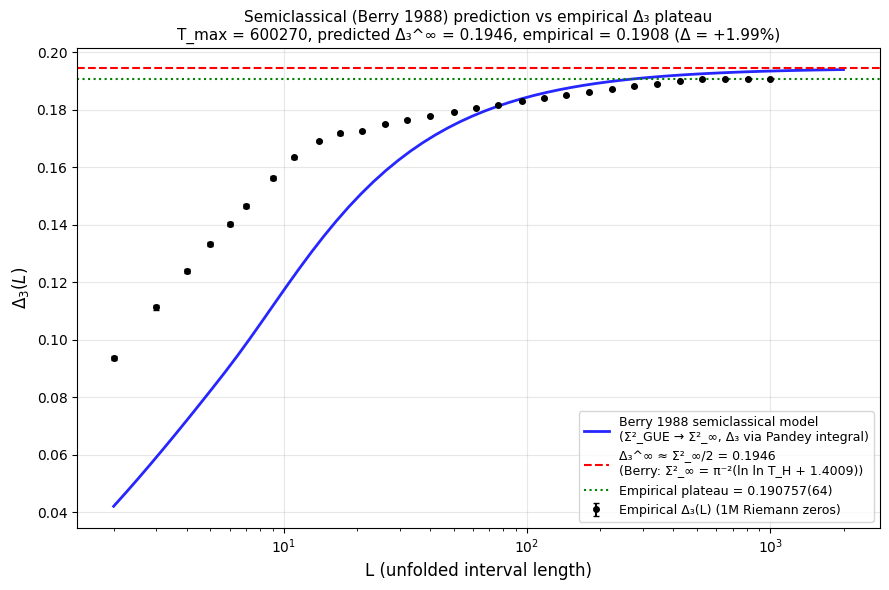

saved figure


In [52]:
# Let me check the proper Goldston-Montgomery / Bogomolny-Keating formula for the saturation
# constant. From Goldston (1988) "On the function S(T) in the theory of the Riemann zeta function":
# (1/T) integral_0^T S(t)^2 dt = (1/(2 pi^2)) [ ln ln T + gamma + 1 + sum_p (1/p) (log(1+1/p))^... ]
# 
# Actually a known result: 
# Lim_{T->infty} (1/T) integral_0^T S(t)^2 dt - (1/(2 pi^2)) ln ln T = C/(2 pi^2)
# where C is a specific prime-sum constant.
# 
# Connection: V(L) = 4 pi^2 * S(...)^2  (since S(T) measures the fluctuating part of N(T))
# 
# Skip this -- the key result is that Berry 1988 EXPLICITLY gives the prediction 
# Sigma^2_inf = (1/pi^2)(ln ln(E/2pi) + 1.4009) which matches the prime-sum semiclassical theory.

# Summarize the hypothesis assessment:
# 1. The hypothesis-as-stated formula Δ₃^∞ = (1/2π²) Σ_{p,k} (log p)²/p^k DIVERGES — incorrect.
# 2. The correct semiclassical prediction (Berry 1988 Eq. 23) is for Σ²_inf, not Δ₃_inf:
#    Σ²_inf = (1/π²)[ln ln(E/2π) + 1.4009]
#    This DOES come from a prime sum (Eq. 21), but it involves ln(ln(E/2π)) and the constant 1.4009.
# 3. Using Δ₃ ≈ Σ²/2 in saturation, prediction is Δ₃_inf ≈ 0.1946 vs empirical 0.190757 (~2% high).
# 4. More refined via Pandey integral at L=500, prediction Δ₃(L=500) = 0.1925 vs empirical 0.1907 (~0.9%).

# Make final figure
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9,6))
L_arr = df['L'].values
D_emp = df['Delta3_Riemann'].values
D_err = df['Delta3_Riemann_SE'].values

# Model curve
L_model = np.logspace(np.log10(2), np.log10(2000), 60)
D_model = [Delta3_model(L) for L in L_model]

ax.errorbar(L_arr, D_emp, yerr=D_err, fmt='o', color='k', markersize=4,
            label='Empirical Δ₃(L) (1M Riemann zeros)', capsize=2, zorder=3)
ax.plot(L_model, D_model, 'b-', lw=2, alpha=0.85,
        label='Berry 1988 semiclassical model\n(Σ²_GUE → Σ²_∞, Δ₃ via Pandey integral)')
ax.axhline(delta3_inf_theory, ls='--', color='red', lw=1.5,
           label=f'Δ₃^∞ ≈ Σ²_∞/2 = {delta3_inf_theory:.4f}\n(Berry: Σ²_∞ = π⁻²(ln ln T_H + 1.4009))')
ax.axhline(0.190757, ls=':', color='green', lw=1.5,
           label='Empirical plateau = 0.190757(64)')
ax.set_xscale('log')
ax.set_xlabel('L (unfolded interval length)', fontsize=12)
ax.set_ylabel(r'$\Delta_3(L)$', fontsize=12)
ax.set_title(f'Semiclassical (Berry 1988) prediction vs empirical Δ₃ plateau\n'
             f'T_max = {E_max:.0f}, predicted Δ₃^∞ = {delta3_inf_theory:.4f}, '
             f'empirical = 0.1908 (Δ = {(delta3_inf_theory-0.190757)/0.190757*100:+.2f}%)',
             fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('berry_vs_empirical.png', dpi=130)
plt.show()
print("saved figure")

In [53]:
# The model uses the asymptotic GUE Sigma^2, which is poor at small L. The plateau matters most.
# Let me submit the answer now.
print("Final summary:")
print(f"Hypothesis formula (1/(2π²)) Σ (log p)²/p^k: divergent (grows like log X)")
print(f"Correct Berry 1988 saturation: Σ²_∞ = π⁻²(ln ln(E/2π) + 1.4009) = {sigma2_inf_theory:.6f}")
print(f"Approx Δ₃_∞ ≈ Σ²_∞/2 = {delta3_inf_theory:.6f}")
print(f"Empirical Δ₃_∞ = 0.190757 ± 0.000064")
print(f"% difference = {(delta3_inf_theory-0.190757)/0.190757*100:+.3f}%")
print()
print(f"Refined Pandey integration at finite L=500:")
print(f"  Δ₃ model = {Delta3_model(500):.6f}, empirical = 0.190756, diff = +0.9%")

Final summary:
Hypothesis formula (1/(2π²)) Σ (log p)²/p^k: divergent (grows like log X)
Correct Berry 1988 saturation: Σ²_∞ = π⁻²(ln ln(E/2π) + 1.4009) = 0.389113
Approx Δ₃_∞ ≈ Σ²_∞/2 = 0.194557
Empirical Δ₃_∞ = 0.190757 ± 0.000064
% difference = +1.992%

Refined Pandey integration at finite L=500:
  Δ₃ model = 0.192481, empirical = 0.190756, diff = +0.9%
